In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mdrazakhan/logistic-regression-dataset/data.csv


In [24]:
df=pd.read_csv('/kaggle/input/datasets/mdrazakhan/logistic-regression-dataset/data.csv')

In [25]:
df.head()

,SNo,X_1,X_2,y
0,0,-0.869144,0.389310,0.0
1,1,-0.993467,-0.610591,0.0
2,2,-0.834064,0.239236,0.0
3,3,-0.136471,0.632003,1.0
4,4,0.403887,0.310784,1.0


In [26]:
df.columns

Index(['SNo', 'X_1', 'X_2', 'y '], dtype='object')

In [41]:
x=df[['X_1','X_2']]
y=df['y ']

In [46]:
y

0     0.0
1     0.0
2     0.0
3     1.0
4     1.0
     ... 
95    1.0
96    1.0
97    1.0
98    1.0
99    1.0
Name: y , Length: 100, dtype: float64

In [42]:
y.shape

(100,)

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [50]:
y_train.shape

(80,)

In [51]:
y_train

96    1.0
89    0.0
30    1.0
1     0.0
33    1.0
     ... 
26    1.0
22    0.0
42    1.0
31    1.0
68    1.0
Name: y , Length: 80, dtype: float64

In [52]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [55]:
y_prob = model.predict_proba(x_test)[:, 1]

In [59]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [60]:
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.8809523809523809


### Draw curve

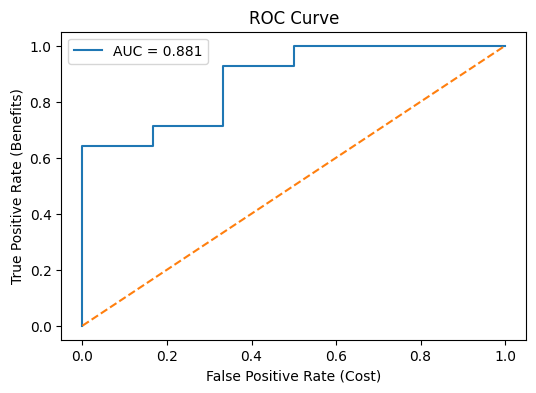

In [62]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate (Cost)")
plt.ylabel("True Positive Rate (Benefits)")
plt.title("ROC Curve")

plt.legend()
plt.show()